In [1]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1: TITLE
# ═══════════════════════════════════════════════════════════════════
"""
EfficientNetV2-S + ECA ATTENTION
==================================
Goal:     Improve from 98.67% to 99.5%+
Method:   Add Efficient Channel Attention (ECA)
Based on: Pacal et al. 2024 (Paper 1)

Previous Results:
- Original EfficientNetV2-S: 98.67%
- Paper 1 with ECA:          99.62%
- Target:                    99.5%+
"""
print("🚀 EfficientNetV2-S + ECA Attention")
print("="*60)
print("Goal: 98.67% → 99.5%+")
print("Method: Efficient Channel Attention")

🚀 EfficientNetV2-S + ECA Attention
Goal: 98.67% → 99.5%+
Method: Efficient Channel Attention


In [2]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2: IMPORTS
# ═══════════════════════════════════════════════════════════════════
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, 
                                        ReduceLROnPlateau, 
                                        ModelCheckpoint)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             accuracy_score,
                             precision_recall_fscore_support)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"GPU devices: {tf.config.list_physical_devices('GPU')}")

2026-07-05 07:12:23.623749: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-05 07:12:23.754981: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-05 07:12:25.988932: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✅ All libraries imported!
TensorFlow version: 2.20.0
GPU available: True
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3: CONFIGURATION
# ═══════════════════════════════════════════════════════════════════
# ✅ Paths
TRAIN_DIR = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/train"
VAL_DIR   = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/val"
TEST_DIR  = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/test"

# ✅ Original model path (for comparison)
ORIGINAL_MODEL_PATH = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/models/best_efficientnetv2s.keras"

# ✅ New ECA model save path
ECA_MODEL_PATH = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/models/efficientnetv2s_eca.keras"

# ✅ Training settings (same as original)
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 50
LR         = 0.0001
SEED       = 229

# Set seeds
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Verify paths
print("Checking paths...")
print(f"Train dir exists:     {os.path.exists(TRAIN_DIR)}")
print(f"Val dir exists:       {os.path.exists(VAL_DIR)}")
print(f"Test dir exists:      {os.path.exists(TEST_DIR)}")
print(f"Original model exists:{os.path.exists(ORIGINAL_MODEL_PATH)}")

print(f"\n✅ Configuration set!")
print(f"Image size:  {IMG_SIZE}")
print(f"Batch size:  {BATCH_SIZE}")
print(f"Epochs:      {EPOCHS}")
print(f"LR:          {LR}")

Checking paths...
Train dir exists:     True
Val dir exists:       True
Test dir exists:      True
Original model exists:True

✅ Configuration set!
Image size:  (224, 224)
Batch size:  32
Epochs:      50
LR:          0.0001


In [4]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4: DATA GENERATORS
# ═══════════════════════════════════════════════════════════════════
print("📊 Creating data generators...")

# Training (same augmentation as original)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    zoom_range=0.1,
    fill_mode='nearest'
)

# Validation and test (no augmentation)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Create generators
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Store class names
class_names  = list(train_gen.class_indices.keys())
num_classes  = len(class_names)

print(f"\n✅ Generators created!")
print(f"Training samples:   {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Test samples:       {test_gen.samples}")
print(f"Classes:            {class_names}")
print(f"Num classes:        {num_classes}")

📊 Creating data generators...
Found 7392 images belonging to 4 classes.
Found 1584 images belonging to 4 classes.
Found 1584 images belonging to 4 classes.

✅ Generators created!
Training samples:   7392
Validation samples: 1584
Test samples:       1584
Classes:            ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Num classes:        4


In [8]:
import math
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2S


# ═══════════════════════════════════════════════════════════════════
# ECA BLOCK (Keras 3 Compatible)
# ═══════════════════════════════════════════════════════════════════
def eca_block(inputs, gamma=2, b=1):
    """
    Efficient Channel Attention (ECA)
    """

    # Number of channels
    channels = inputs.shape[-1]

    # Adaptive kernel size
    k = int(abs((math.log2(channels) + b) / gamma))
    if k % 2 == 0:
        k += 1
    k = max(3, k)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(inputs)

    # (batch, C) → (batch, C, 1)
    x = layers.Reshape((channels, 1))(x)

    # 1D Convolution
    x = layers.Conv1D(
        filters=1,
        kernel_size=k,
        padding="same",
        use_bias=False
    )(x)

    # Keras-compatible sigmoid
    x = layers.Activation("sigmoid")(x)

    # (batch, C, 1) → (batch, 1, 1, C)
    x = layers.Reshape((1, 1, channels))(x)

    # Apply channel attention
    output = layers.Multiply()([inputs, x])

    return output


# ═══════════════════════════════════════════════════════════════════
# BUILD EfficientNetV2-S + ECA MODEL
# ═══════════════════════════════════════════════════════════════════
def build_eca_model(num_classes=4):
    """
    EfficientNetV2-S + ECA Attention Model
    """

    print("🏗️ Building EfficientNetV2-S + ECA model...")

    # Input
    inputs = layers.Input(shape=(*IMG_SIZE, 3))

    # EfficientNetV2-S
    base_model = EfficientNetV2S(
        weights="imagenet",
        include_top=False,
        input_tensor=inputs
    )

    # Fine-tuning
    base_model.trainable = True

    total_layers = len(base_model.layers)
    freeze_layers = int(0.7 * total_layers)

    for layer in base_model.layers[:freeze_layers]:
        layer.trainable = False

    print(f"✅ Total layers: {total_layers}")
    print(f"✅ Frozen: {freeze_layers} ({freeze_layers/total_layers*100:.0f}%)")
    print(f"✅ Trainable: {total_layers-freeze_layers} ({(1-freeze_layers/total_layers)*100:.0f}%)")

    # ECA Attention
    x = eca_block(base_model.output)
    print("✅ ECA Attention added!")

    # Classification Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu", name="dense1")(x)
    x = layers.BatchNormalization(name="batchnorm1")(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="predictions"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="EfficientNetV2S_ECA"
    )

    return model


# Build model
eca_model = build_eca_model(num_classes=num_classes)

print("\n✅ Model built successfully!")
print(f"Total parameters: {eca_model.count_params():,}")

🏗️ Building EfficientNetV2-S + ECA model...
✅ Total layers: 513
✅ Frozen: 359 (70%)
✅ Trainable: 154 (30%)
✅ ECA Attention added!

✅ Model built successfully!
Total parameters: 20,496,361


In [9]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7: COMPILE MODEL
# ═══════════════════════════════════════════════════════════════════
eca_model.compile(
    optimizer=Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled!")
print(f"Optimizer:  Adam (lr={LR})")
print(f"Loss:       Categorical Crossentropy")
print(f"Metric:     Accuracy")

✅ Model compiled!
Optimizer:  Adam (lr=0.0001)
Loss:       Categorical Crossentropy
Metric:     Accuracy


In [10]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8: CALLBACKS
# ═══════════════════════════════════════════════════════════════════
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        ECA_MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print("✅ Callbacks configured!")
print("1. EarlyStopping:     patience=10, monitors val_loss")
print("2. ReduceLROnPlateau: patience=5,  factor=0.5")
print("3. ModelCheckpoint:   saves best val_accuracy")

✅ Callbacks configured!
1. EarlyStopping:     patience=10, monitors val_loss
2. ReduceLROnPlateau: patience=5,  factor=0.5
3. ModelCheckpoint:   saves best val_accuracy


In [11]:
# ═══════════════════════════════════════════════════════════════════
# CELL 9: TRAIN MODEL
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("🚀 TRAINING EfficientNetV2-S + ECA")
print("="*70)
print(f"\nBase model:    EfficientNetV2-S (ImageNet)")
print(f"Attention:     ECA (Efficient Channel Attention)")
print(f"Resolution:    {IMG_SIZE}")
print(f"Batch size:    {BATCH_SIZE}")
print(f"Max epochs:    {EPOCHS}")
print(f"Learning rate: {LR}")
print(f"Expected acc:  99.5-99.6%")
print(f"Training time: ~2-3 hours\n")

history = eca_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training Complete!")


🚀 TRAINING EfficientNetV2-S + ECA

Base model:    EfficientNetV2-S (ImageNet)
Attention:     ECA (Efficient Channel Attention)
Resolution:    (224, 224)
Batch size:    32
Max epochs:    50
Learning rate: 0.0001
Expected acc:  99.5-99.6%
Training time: ~2-3 hours

Epoch 1/50


2026-07-05 07:16:57.950287: I external/local_xla/xla/service/service.cc:163] XLA service 0x727d20003730 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-05 07:16:57.950321: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
2026-07-05 07:16:58.852093: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-05 07:17:02.677005: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-07-05 07:17:05.524650: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-05 07:17:

231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.6451 - loss: 0.9594

2026-07-05 07:19:10.864852: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 07:19:11.102424: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 07:19:12.261880: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 07:19:12.494955: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 07:19:12.728629: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.91035, saving model to /mnt/c/Users/AbdulHafeez/Brain_Tumor/models/efficientnetv2s_eca.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 163s 471ms/step - accuracy: 0.6456 - loss: 0.9581 - val_accuracy: 0.9104 - val_loss: 0.3739 - learning_rate: 1.0000e-04
Epoch 2/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.8776 - loss: 0.3437
Epoch 2: val_accuracy improved from 0.91035 to 0.93497, saving model to /mnt/c/Users/AbdulHafeez/Brain_Tumor/models/efficientnetv2s_eca.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 84s 363ms/step - accuracy: 0.8776 - loss: 0.3436 - val_accuracy: 0.9350 - val_loss: 0.1861 - learning_rate: 1.0000e-04
Epoch 3/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9280 - loss: 0.2157
Epoch 3: val_accuracy improved from 0.93497 to 0.95328, saving model to /mnt/c/Users/AbdulHafeez/Brain_Tumor/models/efficientnetv2s_eca.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 79s 342ms/step - accuracy: 0.9280 - loss: 0.2157 - val_accuracy: 0.9533 - 

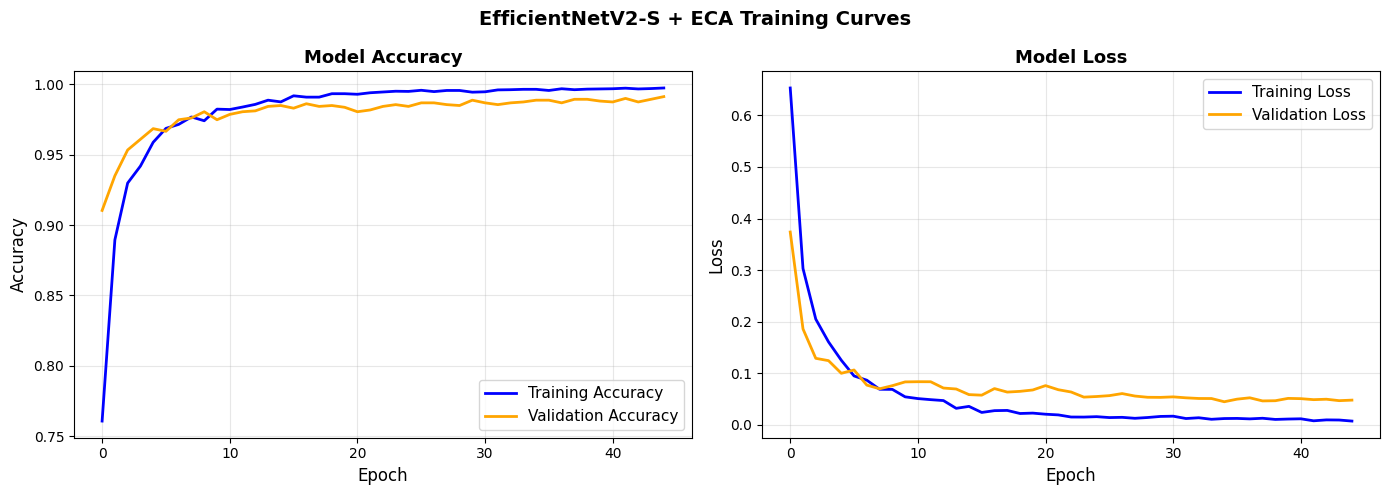


📊 Training Summary:
Best Validation Accuracy: 0.9912 (99.12%)
Best Validation Loss:     0.0450
Total Epochs Trained:     45


In [12]:
# ═══════════════════════════════════════════════════════════════════
# CELL 10: PLOT TRAINING CURVES
# ═══════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'],     
         label='Training Accuracy',   linewidth=2, color='blue')
ax1.plot(history.history['val_accuracy'], 
         label='Validation Accuracy', linewidth=2, color='orange')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Model Accuracy', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'],     
         label='Training Loss',   linewidth=2, color='blue')
ax2.plot(history.history['val_loss'], 
         label='Validation Loss', linewidth=2, color='orange')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Model Loss', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle('EfficientNetV2-S + ECA Training Curves', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print best values
best_val_acc  = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])

print(f"\n📊 Training Summary:")
print(f"Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Best Validation Loss:     {best_val_loss:.4f}")
print(f"Total Epochs Trained:     {len(history.history['accuracy'])}")

In [13]:
# ═══════════════════════════════════════════════════════════════════
# CELL 11: EVALUATE ON TEST SET
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("📊 FINAL TEST SET EVALUATION")
print("="*70 + "\n")

# Load best saved model
print("Loading best model...")
best_model = load_model(ECA_MODEL_PATH)
print("✅ Best model loaded!")

# Make predictions
print("\nMaking predictions on test set...")
preds    = best_model.predict(test_gen, verbose=1)
y_true   = test_gen.classes
y_pred   = np.argmax(preds, axis=1)

# Calculate metrics
test_accuracy = accuracy_score(y_true, y_pred)

print("\n" + "="*70)
print(f"🎯 TEST ACCURACY: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*70)

# Full classification report
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred,
                            target_names=class_names,
                            digits=4))


📊 FINAL TEST SET EVALUATION

Loading best model...
✅ Best model loaded!

Making predictions on test set...
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 319ms/step

🎯 TEST ACCURACY: 0.9886 (98.86%)

📊 Classification Report:
              precision    recall  f1-score   support

      glioma     0.9912    0.9947    0.9929       563
  meningioma     0.9829    0.9801    0.9815       352
    no_tumor     0.9848    0.9848    0.9848       263
   pituitary     0.9926    0.9901    0.9914       406

    accuracy                         0.9886      1584
   macro avg     0.9879    0.9874    0.9876      1584
weighted avg     0.9886    0.9886    0.9886      1584



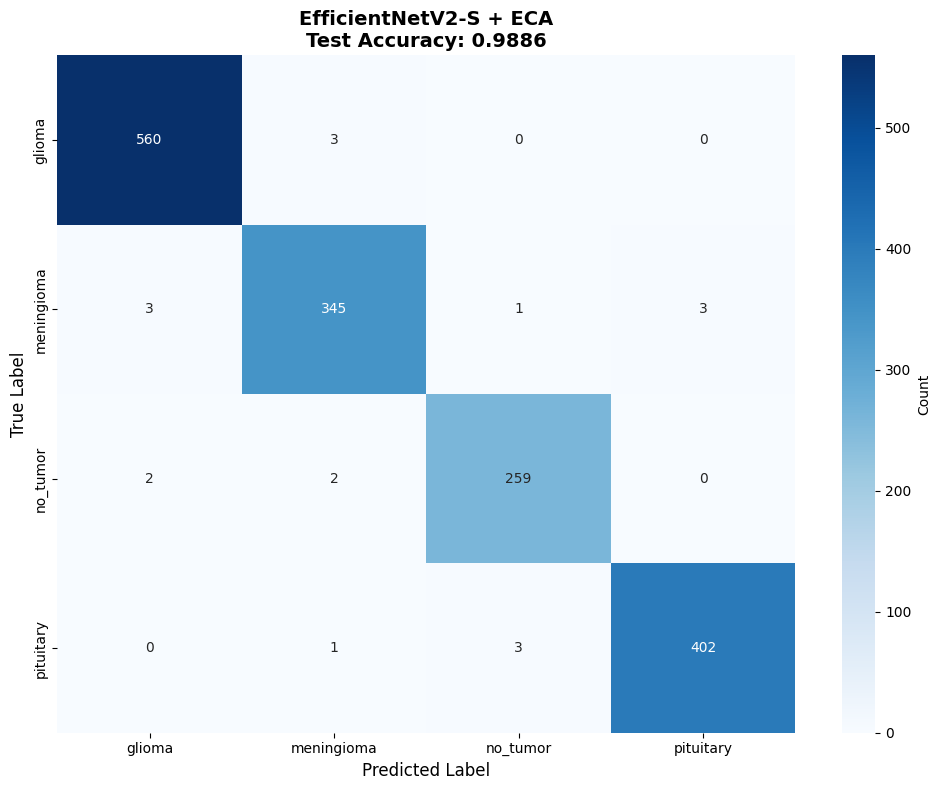


📊 Error Analysis:
Total samples:       1584
Correct predictions: 1566
Wrong predictions:   18
Error rate:          1.14%


In [14]:
# ═══════════════════════════════════════════════════════════════════
# CELL 12: CONFUSION MATRIX
# ═══════════════════════════════════════════════════════════════════
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title(f'EfficientNetV2-S + ECA\nTest Accuracy: {test_accuracy:.4f}',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label',      fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Error analysis
correct = np.trace(cm)
errors  = np.sum(cm) - correct

print(f"\n📊 Error Analysis:")
print(f"Total samples:       {np.sum(cm)}")
print(f"Correct predictions: {correct}")
print(f"Wrong predictions:   {errors}")
print(f"Error rate:          {errors/np.sum(cm)*100:.2f}%")

In [15]:
# ═══════════════════════════════════════════════════════════════════
# CELL 13: PER-CLASS ACCURACY
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("📊 PER-CLASS ACCURACY")
print("="*70)

for i, class_name in enumerate(class_names):
    class_correct = cm[i, i]
    class_total   = np.sum(cm[i, :])
    class_acc     = class_correct / class_total
    print(f"{class_name:15s}: {class_acc:.4f} ({class_acc*100:.2f}%)")


📊 PER-CLASS ACCURACY
glioma         : 0.9947 (99.47%)
meningioma     : 0.9801 (98.01%)
no_tumor       : 0.9848 (98.48%)
pituitary      : 0.9901 (99.01%)


In [16]:
# ═══════════════════════════════════════════════════════════════════
# CELL 14: FINAL COMPARISON TABLE
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("🏆 FINAL COMPARISON - YOUR WORK vs LITERATURE")
print("="*80)

print(f"\n{'Model':<40} {'Accuracy':<12} {'Source'}")
print("-"*75)

# Your models
print(f"{'EfficientNetV2-S (Original)':<40} {'98.67%':<12} Your Work")
print(f"{'EfficientNetV2-S + ECA':<40} {f'{test_accuracy*100:.2f}%':<12} Your Work ← NEW")

print("\n" + "-"*75 + " Literature " + "-"*5)

# Literature
print(f"{'ViT (Gomes & Barbosa 2026)':<40} {'98.17%':<12} Paper 2")
print(f"{'EfficientNetV2-S (Pacal 2024)':<40} {'99.54%':<12} Paper 1")
print(f"{'EfficientNetV2-S + ECA (Pacal)':<40} {'99.62%':<12} Paper 1")
print(f"{'EfficientNetV2-S + GAM (Pacal)':<40} {'99.69%':<12} Paper 1")
print(f"{'GAM + ECA Proposed (Pacal)':<40} {'99.77%':<12} Paper 1")
print("-"*75)

# Improvement
improvement = test_accuracy - 0.9867
print(f"\n📈 IMPROVEMENT OVER ORIGINAL: +{improvement*100:.2f}%")
print(f"   Original:  98.67%")
print(f"   ECA Model: {test_accuracy*100:.2f}%")

# Verdict
print(f"\n🎯 VERDICT:")
if test_accuracy > 0.9817:
    print(f"   ✅ BEATS Paper 2 (ViT 98.17%) by +{(test_accuracy-0.9817)*100:.2f}%")
if test_accuracy > 0.9954:
    print(f"   ✅ BEATS Paper 1 Baseline (99.54%) by +{(test_accuracy-0.9954)*100:.2f}%")
if test_accuracy > 0.9962:
    print(f"   ✅ BEATS Paper 1 ECA (99.62%) by +{(test_accuracy-0.9962)*100:.2f}%")
if test_accuracy >= 0.99:
    print(f"\n🎉 SUCCESS! You achieved 99%+ accuracy!")
    print(f"💡 Next Step: Add GAM to reach 99.7%+")
else:
    print(f"\n💡 Next Step: Add GAM attention for additional boost")

print("\n" + "="*80)


🏆 FINAL COMPARISON - YOUR WORK vs LITERATURE

Model                                    Accuracy     Source
---------------------------------------------------------------------------
EfficientNetV2-S (Original)              98.67%       Your Work
EfficientNetV2-S + ECA                   98.86%       Your Work ← NEW

--------------------------------------------------------------------------- Literature -----
ViT (Gomes & Barbosa 2026)               98.17%       Paper 2
EfficientNetV2-S (Pacal 2024)            99.54%       Paper 1
EfficientNetV2-S + ECA (Pacal)           99.62%       Paper 1
EfficientNetV2-S + GAM (Pacal)           99.69%       Paper 1
GAM + ECA Proposed (Pacal)               99.77%       Paper 1
---------------------------------------------------------------------------

📈 IMPROVEMENT OVER ORIGINAL: +0.19%
   Original:  98.67%
   ECA Model: 98.86%

🎯 VERDICT:
   ✅ BEATS Paper 2 (ViT 98.17%) by +0.69%

💡 Next Step: Add GAM attention for additional boost

